In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Sample - Superstore.csv" , encoding ='cp1252' )
df.columns.tolist()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

# **TASK 1**

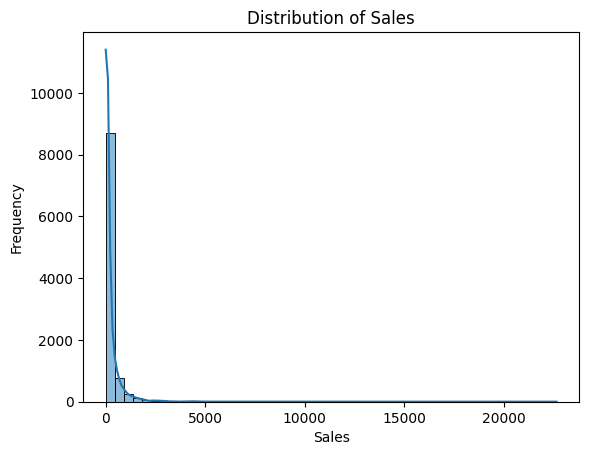

MEAN :  229.85800083049833
MEDIAN :  54.489999999999995
SKEWNESS :  12.97275234181623


In [10]:
sns.histplot(data=df, x='Sales', kde=True , bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

print("MEAN : ", df['Sales'].mean())
print("MEDIAN : " , df['Sales'].median())
print("SKEWNESS : " , df['Sales'].skew())

Sales data is usually skewed to the right, meaning the mean is higher than the median because of a few very large sales. Because these large numbers pull the average up, the median is a better choice to show the typical sales value.



# **TASK 2**

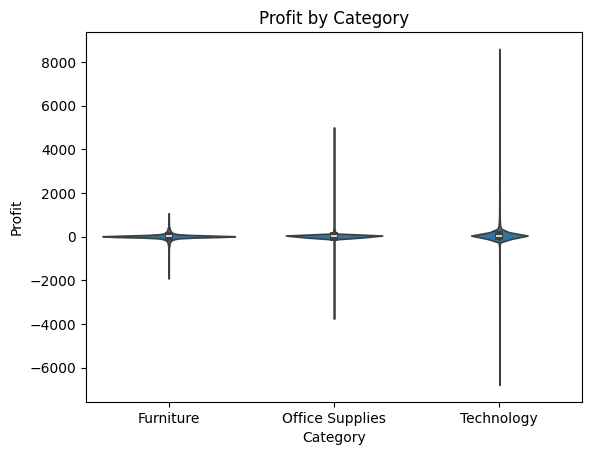

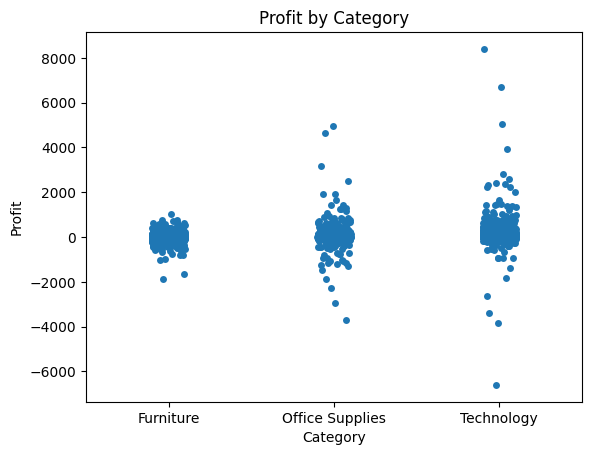

In [6]:
#task 2
sns.violinplot(data = df , x= 'Category' , y='Profit')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()


sns.stripplot(data = df , x= 'Category' , y='Profit')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()


The violin plot is better for showing double peaks or wide spreads because its smooth shape highlights where data splits or spreads out. A strip plot just shows a bunch of dots that overlap and blur together in crowded areas.

# **TASK 3**



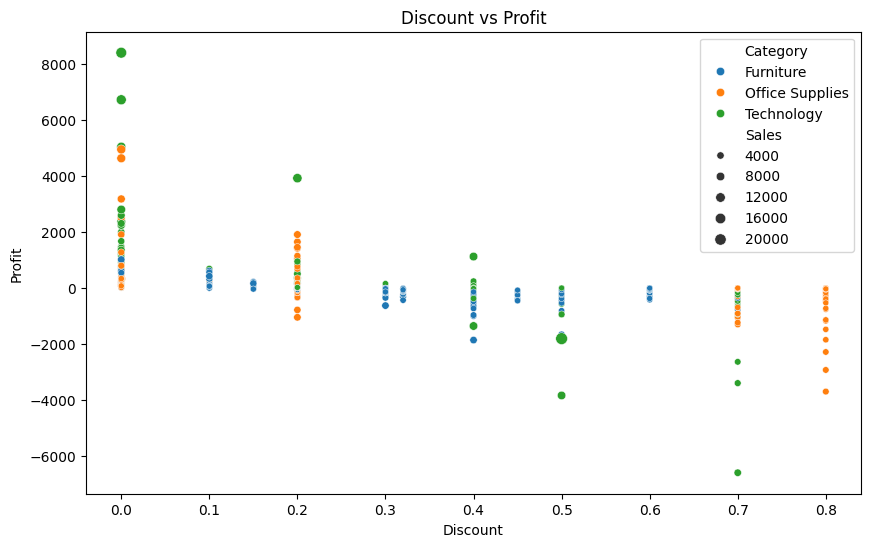

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df , x= 'Discount', y = 'Profit' , hue='Category' , size='Sales')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()


By using colors for categories and dot sizes for sales, can see that huge sales with high discounts still result in massive profit losses a pattern we miss if only looked at the discount and profit alone such as office supplies profit decrease with discount

# **TASK 4**

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000

                Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.011466 -0.001310 -0.002416  0.012655 -0.010545
Postal Code  0.011466     1.000000 -0.002059  0.013952  0.052793 -0.005451
Sales       -0.001310    -0.002059  1.000000  0.327426 -0.056969  0.518407
Quantity    -0.002416     0.013952  0.327426  1.000000 -0.000878  0.234491
Discount     0.012655     0.052793 -0.056969 -0.000878  1.000000 -0.543350
Profit      -0.010545  

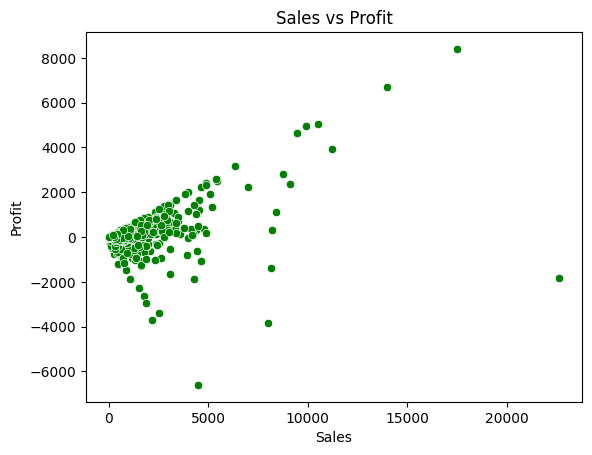

In [57]:
corr_matrix_pearson = df.select_dtypes(include='number').corr(method='pearson')
print(corr_matrix_pearson)

corr_matrix_spearman = df.select_dtypes(include='number').corr(method='spearman')
print("\n" , corr_matrix_spearman)

sns.scatterplot(data = df , x= 'Sales' , y= 'Profit' , color='green')
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

They disagree because the relationship between sales and profit is non linear and with extreme outliers. A few massive sales transactions have giant profits or giant losses, which throws off Pearson's straight line math spearman ranks the data instead of using the raw numbers which protects it from these wild outliers and reveals a stronger pward trend

# **Task 5**

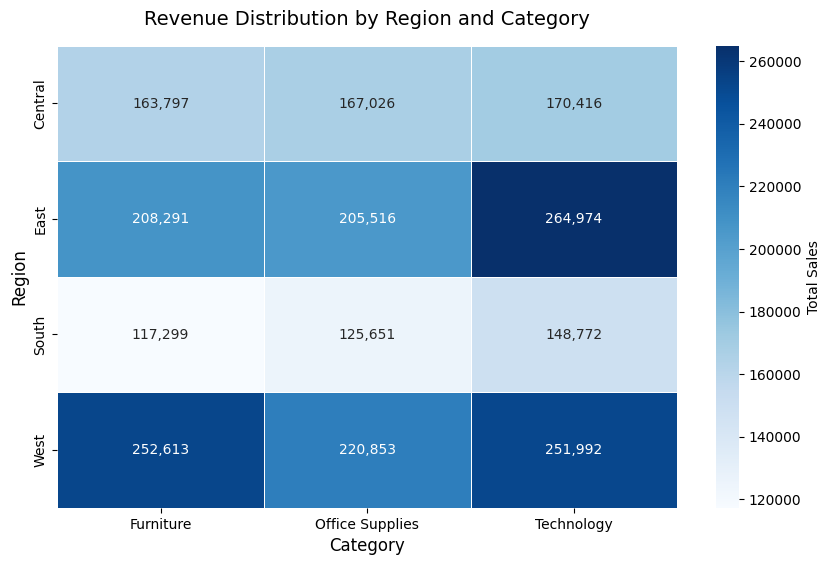

In [58]:
pivot_sales = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum', margins=True, margins_name='Total')

heatmap_data = pivot_sales.drop(index='Total', columns='Total')

top_region, top_category = heatmap_data.unstack().idxmax()
top_revenue = heatmap_data.loc[top_category, top_region]

plt.figure(figsize=(10, 6))
sns.heatmap( heatmap_data, annot=True, fmt=",.0f", cmap="Blues", linewidths=0.5, cbar_kws={'label': 'Total Sales'})



plt.title("Revenue Distribution by Region and Category", fontsize=14, pad=15)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.show()

Technology east contributes the most

# **Task 6**

/tmp/ipykernel_2448/3419226201.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


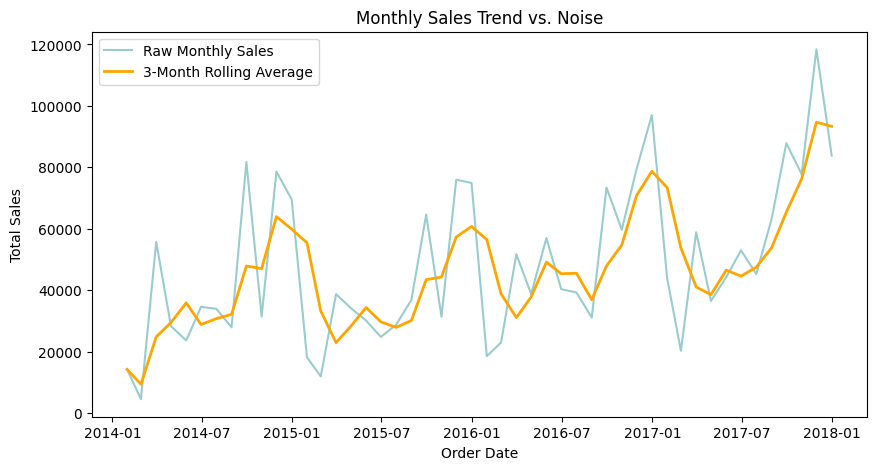

In [53]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
rolling_sales = monthly_sales.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Raw Monthly Sales', alpha=0.4, color='teal')
plt.plot(rolling_sales.index, rolling_sales.values, label='3-Month Rolling Average', color='orange', linewidth=2)
plt.title('Monthly Sales Trend vs. Noise')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

The 3 month rolling average smooths out shortterm fluctuations and random spikes in the raw monthly sales making the underlying sales trend easier to see it also reveals the overall upward movement and recurring patterns that are less obvious in the normal monthly line

# **TASK 7**

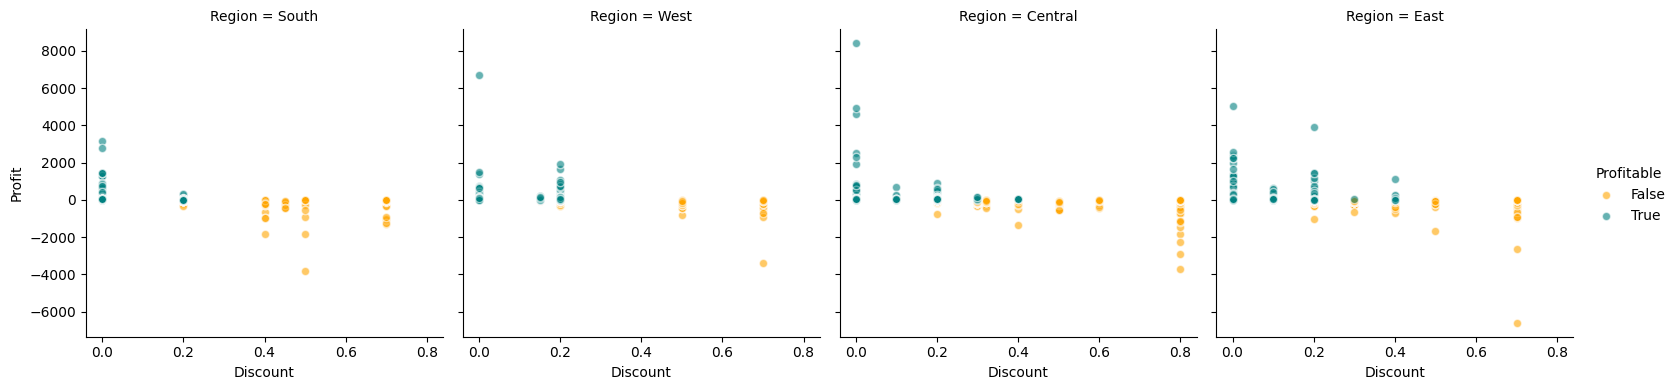

In [41]:
df['Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col="Region", hue="Profitable", palette={True: "teal", False: "orange"}, height=4, aspect=1)
g.map(plt.scatter, "Discount", "Profit", alpha=0.6, edgecolor='w')
g.add_legend(title="Profitable")

plt.show()

Central

# **TASK 8**

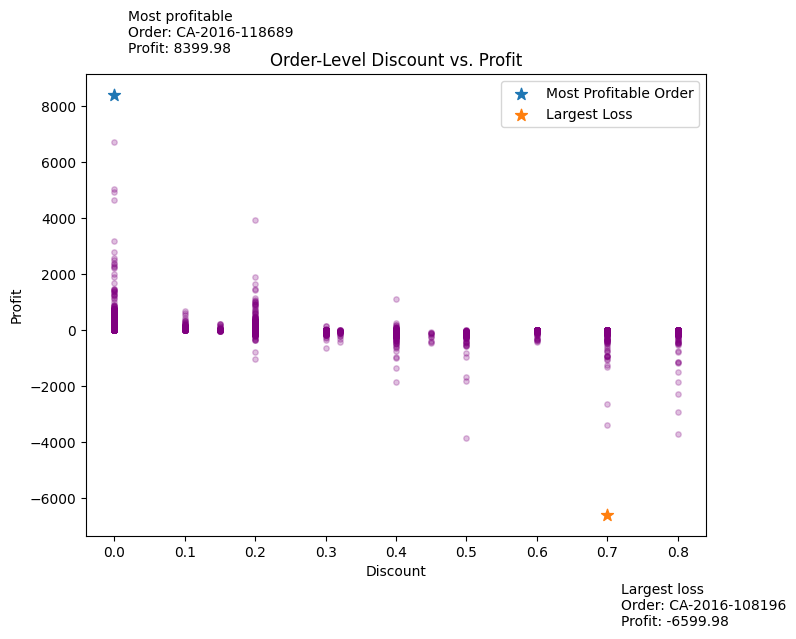

In [55]:
max_profit = df.loc[df['Profit'].idxmax()]
min_profit = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.25,
    s=15,
    color ='purple'
)

plt.scatter(
    max_profit['Discount'],
    max_profit['Profit'],
    s=80,
    marker='*',
    label='Most Profitable Order'
)

plt.scatter(
    min_profit['Discount'],
    min_profit['Profit'],
    s=80,
    marker='*',
    label='Largest Loss'
)

plt.annotate(
    f"Most profitable\nOrder: {max_profit['Order ID']}\nProfit: {max_profit['Profit']:.2f}",
    (max_profit['Discount'], max_profit['Profit']),
    xytext=(10, 30),
    textcoords='offset points'
)

plt.annotate(
    f"Largest loss\nOrder: {min_profit['Order ID']}\nProfit: {min_profit['Profit']:.2f}",
    (min_profit['Discount'], min_profit['Profit']),
    xytext=(10, -80),
    textcoords='offset points'
)

plt.title('Order-Level Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend()
plt.show()

alpha transparency is suitable because the order count is manageable and reducing point opacity makes dense regions visible without losing individual observations